Measure first-order interest rate sensitivity

Measure second-order sensitivity

Understand duration as a weighted average maturity

Calculate bond and portfolio risk

Analyse exposure to specific points on the yield curve

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline

In [30]:
from pathlib import Path

ROOT = Path.cwd().parent

In [31]:
curve = pd.read_csv(ROOT / "data/continuous_zero_curve.csv")
portfolio = pd.read_csv(ROOT / "data/sample_portfolio.csv")

display(curve)
display(portfolio)

,Years,Spot
0,0.250000,3.870000
1,0.309619,3.919838
2,0.369238,3.960059
3,0.428858,3.991767
4,0.488477,4.016065
...,...,...
495,29.761523,5.302691
496,29.821142,5.293485
497,29.880762,5.284153
498,29.940381,5.274696


,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight
0,2Y,2,2000000.0,4.11,99.714968,1.994299e+06,0.202066
1,5Y,5,3000000.0,4.17,99.108831,2.973265e+06,0.301256
2,7Y,7,1500000.0,4.28,98.685838,1.480288e+06,0.149985
3,10Y,10,2500000.0,4.41,98.242813,2.456070e+06,0.248853
4,20Y,20,1000000.0,4.87,96.564307,9.656431e+05,0.097840


In [32]:
spot_curve = CubicSpline(
    curve["Years"],
    curve["Spot"]
)

In [33]:
def discount_factor(t):

    r = spot_curve(t) / 100

    return 1 / (1 + r) ** t


def cashflows(maturity, coupon_rate, freq = 2, face = 100):

    periods = int(maturity * freq)

    payment = (coupon_rate / 100 * face / freq)

    times = np.arange(1, periods+1) / freq

    cashflows = np.full(
        periods,
        payment
    )

    cashflows[-1] += face

    return times, cashflows

def price_bond(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency, face)

    dfs = discount_factor(times)

    return np.sum(cf * dfs)

def price_bond_curve(maturity, coupon_rate, curve, face = 100, frequency = 2):

    spline = CubicSpline(curve["Years"], curve["Spot"])

    times, cf = cashflows(maturity, coupon_rate, frequency, face)

    spot = spline(times) / 100

    discount = 1 / (1 + spot) ** times

    return np.sum(cf * discount)

def shift_curve(curve, shift_bp):

    shocked = curve.copy()

    shocked["Spot"] += shift_bp / 100

    return shocked

# Macaulay duration
def macaulay_duration(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency, face)

    df = discount_factor(times)

    pv = cf * df

    price = pv.sum()

    duration = np.sum(times * pv) / price

    return duration

# Effective duration
def eff_duration(maturity, coupon_rate, curve, face = 100, frequency = 2, dy = 1):

    curve_up = shift_curve(curve, dy)
    curve_down = shift_curve(curve, -dy)

    P_up = price_bond_curve(maturity, coupon_rate, curve_up, face, frequency)

    P_down = price_bond_curve(maturity, coupon_rate, curve_down, face, frequency)

    P0 = price_bond_curve(maturity, coupon_rate, curve, face, frequency)

    delta_y = dy / 10000

    return (P_down - P_up) / (2 * P0 * delta_y)

# Effective convexity via central difference
def eff_convexity(maturity, coupon_rate, curve, face = 100, frequency = 2, dy = 1):

    curve_up = shift_curve(curve, dy)
    curve_down = shift_curve(curve, -dy)

    P_up = price_bond_curve(maturity, coupon_rate, curve_up, face, frequency)
    
    P_down = price_bond_curve(maturity, coupon_rate, curve_down, face, frequency)

    P0 = price_bond_curve(maturity, coupon_rate, curve, face, frequency)

    delta_y = dy / 10000

    return (P_up + P_down - 2 * P0) / (P0 * delta_y ** 2)

# DV01 / PV01
def dv01(maturity, coupon_rate, curve, face = 100, frequency = 2):

    P0 = price_bond_curve(maturity, coupon_rate, curve, face, frequency)

    shocked = shift_curve(curve, 1)

    P1 = price_bond_curve(maturity, coupon_rate, shocked, face, frequency)

    return P0 - P1
    

In [34]:
portfolio["Duration"] = portfolio.apply(
    lambda row: eff_duration(
        row["Maturity"],
        row["Coupon"],
        curve
    ),
    axis=1
)

portfolio["Convexity"] = portfolio.apply(
    lambda row: eff_convexity(
        row["Maturity"],
        row["Coupon"],
        curve
    ),
    axis=1
)

portfolio["DV01"] = portfolio.apply(
    lambda row: (
        dv01(
            row["Maturity"],
            row["Coupon"],
            curve
        )
        * row["Face"] / 100
    ),
    axis=1
)


In [35]:
portfolio

,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight,Duration,Convexity,DV01
0,2Y,2,2000000.0,4.11,99.714968,1.994299e+06,0.202066,1.860114,5.304330,370.909573
1,5Y,5,3000000.0,4.17,99.108831,2.973265e+06,0.301256,4.368260,24.382197,1298.437005
2,7Y,7,1500000.0,4.28,98.685838,1.480288e+06,0.149985,5.844855,42.769879,864.890092
3,10Y,10,2500000.0,4.41,98.242813,2.456070e+06,0.248853,7.793928,76.377549,1913.305626
4,20Y,20,1000000.0,4.87,96.564307,9.656431e+05,0.097840,12.023562,200.833923,1160.077246


In [36]:
# Portfolio statistics
portfolio_duration = np.sum(
    portfolio["Weight"] * portfolio["Duration"]
)

portfolio_convexity = np.sum(
    portfolio["Weight"] * portfolio["Convexity"]
)

portfolio_dv01 = portfolio["DV01"].sum()

print(portfolio_duration)
print(portfolio_convexity)
print(portfolio_dv01)
display(portfolio)

5.684403441579196
53.48841398061441
5607.619543397817


,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight,Duration,Convexity,DV01
0,2Y,2,2000000.0,4.11,99.714968,1.994299e+06,0.202066,1.860114,5.304330,370.909573
1,5Y,5,3000000.0,4.17,99.108831,2.973265e+06,0.301256,4.368260,24.382197,1298.437005
2,7Y,7,1500000.0,4.28,98.685838,1.480288e+06,0.149985,5.844855,42.769879,864.890092
3,10Y,10,2500000.0,4.41,98.242813,2.456070e+06,0.248853,7.793928,76.377549,1913.305626
4,20Y,20,1000000.0,4.87,96.564307,9.656431e+05,0.097840,12.023562,200.833923,1160.077246


In [37]:
# Compute KRD
def price_portfolio(portfolio, curve):

    total = 0

    for _, row in portfolio.iterrows():

        price = price_bond_curve(
            row["Maturity"],
            row["Coupon"],
            curve
        )

        total += (
            price
            * row["Face"]
            / 100
        )

    return total

def key_rate_shift(curve, maturity, shock_bp=1):

    shocked = curve.copy()

    idx = (shocked["Years"] - maturity).abs().idxmin()

    shocked.loc[idx, "Spot"] += shock_bp / 100

    return shocked



In [38]:
key_rates = [2,5,7,10,20]

base = price_portfolio(portfolio, curve)

krd = {}

for k in key_rates:

    shocked = key_rate_shift(curve, k, shock_bp = 1)

    shocked_price = price_portfolio(portfolio, shocked)

    krd[k] = (base - shocked_price) / (base * 0.0001) # delta_y = 1bp

In [39]:
krd = pd.DataFrame({

    "Key Rate": krd.keys(),

    "Duration": krd.values()

})

In [40]:
shocks = pd.read_csv(ROOT / "data/parallel_shocks.csv")
shocks

,Unnamed: 0,Shocks,PnL
0,0,-200,1.237521
1,1,-150,0.905011
2,2,-100,0.588605
3,3,-50,0.287257
4,4,0,0.000000
5,5,50,-0.274053
6,6,100,-0.535723
7,7,150,-0.785765
8,8,200,-1.024880


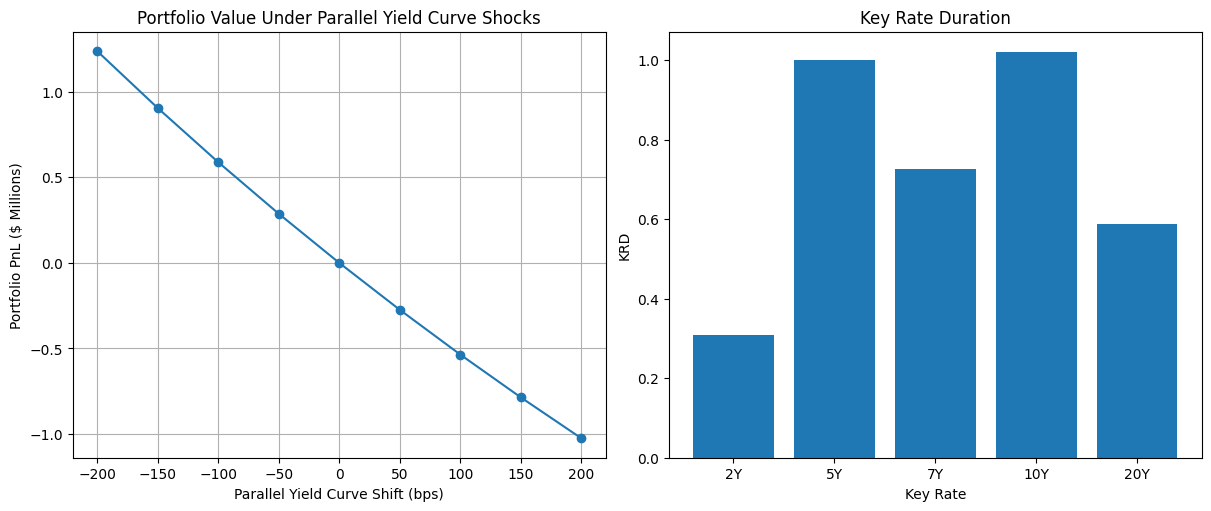

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

axes[1].bar(["2Y", "5Y", "7Y", "10Y", "20Y"], krd["Duration"])
axes[1].set_xlabel("Key Rate")
axes[1].set_ylabel("KRD")
axes[1].set_title("Key Rate Duration")

axes[0].plot(shocks["Shocks"], shocks["PnL"], marker="o")
axes[0].set_xlabel("Parallel Yield Curve Shift (bps)")
axes[0].set_ylabel("Portfolio PnL ($ Millions)")
axes[0].set_title("Portfolio Value Under Parallel Yield Curve Shocks")
axes[0].grid(True)

plt.savefig(ROOT / "outputs/parallel_shocks_KRD.png")

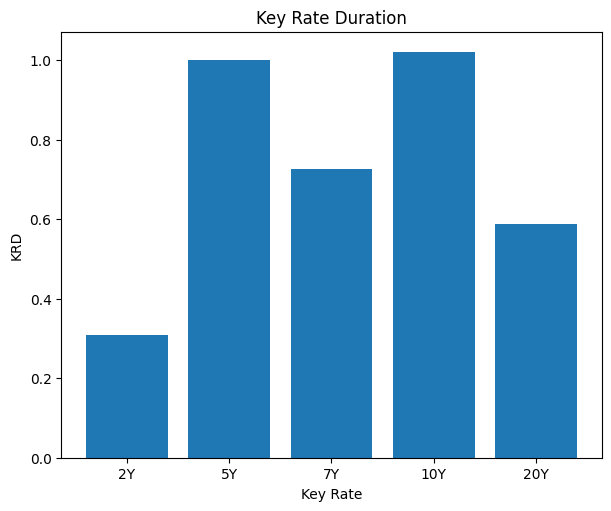

In [42]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

ax.bar(["2Y", "5Y", "7Y", "10Y", "20Y"], krd["Duration"])
ax.set_xlabel("Key Rate")
ax.set_ylabel("KRD")
ax.set_title("Key Rate Duration")

plt.savefig(ROOT / "outputs/KRD.png")


In [43]:
# Duration approximation
actual = []
duration_only = []
duration_convexity = []

P0 = price_portfolio(portfolio, curve)
D = portfolio_duration
C = portfolio_convexity

shifts = np.arange(-2, 2.25, 0.25)
for s in shifts:

    shocked = shift_curve(curve, s*100)

    actual.append(price_portfolio(portfolio, shocked)) # Reprice completely

    dy = s/100

    duration_only.append(

        P0 * (1 - D * dy)

    )

    duration_convexity.append(

        P0 * (1 - D * dy + 0.5 * C * dy ** 2)

    )

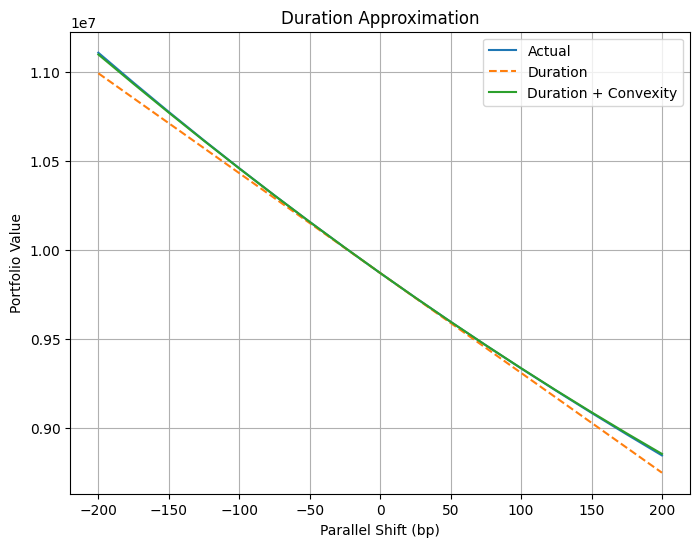

In [44]:
plt.figure(figsize=(8,6))

plt.plot(shifts * 100, actual, label = "Actual")

plt.plot(shifts * 100, duration_only, ls = "--", label = "Duration")

plt.plot(shifts * 100, duration_convexity, label = "Duration + Convexity")

plt.xlabel("Parallel Shift (bp)")
plt.ylabel("Portfolio Value")
plt.title("Duration Approximation")

plt.legend()
plt.grid()

plt.savefig(ROOT / "outputs/duration_approximation.png")

In [46]:
# Risk summary
risk_summary = pd.DataFrame({

    "Metric":["Portfolio Value", "Effective Duration", "Effective Convexity", "Portfolio DV01"],
    "Value":[base, portfolio_duration, portfolio_convexity, portfolio_dv01]

})

risk_summary

,Metric,Value
0,Portfolio Value,9.869565e+06
1,Effective Duration,5.684403e+00
2,Effective Convexity,5.348841e+01
3,Portfolio DV01,5.607620e+03


In [47]:
portfolio

,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight,Duration,Convexity,DV01
0,2Y,2,2000000.0,4.11,99.714968,1.994299e+06,0.202066,1.860114,5.304330,370.909573
1,5Y,5,3000000.0,4.17,99.108831,2.973265e+06,0.301256,4.368260,24.382197,1298.437005
2,7Y,7,1500000.0,4.28,98.685838,1.480288e+06,0.149985,5.844855,42.769879,864.890092
3,10Y,10,2500000.0,4.41,98.242813,2.456070e+06,0.248853,7.793928,76.377549,1913.305626
4,20Y,20,1000000.0,4.87,96.564307,9.656431e+05,0.097840,12.023562,200.833923,1160.077246
